## Implementacja sieci Kohonena - wczytanie danych

In [1]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from collections import Counter

In [3]:
df_hex = pd.read_csv('kohonen_data/hexagon.csv')
df_cube = pd.read_csv('kohonen_data/cube.csv')

In [4]:
X_treningowe = df_hex[['x', 'y']].values

In [5]:
etykiety_klas_hex = df_hex['c'].values

In [6]:
scaler = MinMaxScaler()
X_gotowe_hex = scaler.fit_transform(X_treningowe)

In [7]:
X_gotowe_hex[:5]

array([[0.74968175, 0.73488462],
       [0.4200263 , 0.93217116],
       [0.72823557, 0.37087037],
       [0.83334619, 0.66741976],
       [0.83271504, 0.38523445]])

In [8]:
X_treningowe = df_cube[['x', 'y', 'z']].values

In [9]:
etykiety_klas_cube = df_hex['c'].values

In [10]:
scaler = MinMaxScaler()
X_gotowe_cube = scaler.fit_transform(X_treningowe)

In [11]:
X_gotowe_cube[:5]

array([[0.31133808, 0.29995395, 0.38199276],
       [0.09697057, 0.25404951, 0.12459394],
       [0.14299692, 0.3527554 , 0.30185374],
       [0.41692037, 0.34404072, 0.2809998 ],
       [0.27031328, 0.27175274, 0.19666808]])

## Imlementacja sieci Kohonena

### Inicjalizacja architektury

In [12]:
class KohonenNetwork:
    def __init__(self, m, n):
        self.m = m
        self.n = n
        self.weights = None
        x_coords, y_coords = np.meshgrid(np.arange(m), np.arange(n), indexing='ij')
        self.grid_coords = np.stack([x_coords, y_coords], axis=-1)
        
    def _initialize_weights(self, num_features):
        """
        Inicjalizuje wagi neuronów losowymi wartościami z przedziału [0, 1].
        Wywoływane automatycznie przy pierwszym uruchomieniu uczenia.
        """
        self.weights = np.random.rand(self.m, self.n, num_features)
        print(f"Zainicjalizowano wagi o wymiarach: {self.weights.shape}")
    def _learning_rate(self, t, lambda_param):
        """
        Współczynnik uczenia wygasający w czasie.
        t: aktualna iteracja/epoka
        lambda_param: stała kontrolująca tempo spadku (np. max_epok / 2)
        """
        return np.exp(-t / lambda_param)

    def _neighborhood_gaussian(self, x, c):
        """
        Funkcja sąsiedztwa 1: Gaussowska.
        x: macierz odległości topologicznych wszystkich neuronów od BMU
        c: parametr szerokości sąsiedztwa
        """
        return np.exp(-(c * x)**2)

    def _neighborhood_mexican_hat(self, x, c):
        """
        Funkcja sąsiedztwa 2: Minus druga pochodna Gaussa (Meksykański Kapelusz).
        x: macierz odległości topologicznych wszystkich neuronów od BMU
        c: parametr szerokości sąsiedztwa
        """
        cx_sq = (c * x)**2 
        return (1 - cx_sq) * np.exp(-cx_sq / 2)
    def fit(self, X, epochs=100, neighborhood_func='gaussian', c=1.0):
        """
        Główna pętla ucząca sieć Kohonena.
        X: zbiór danych treningowych (np. X_gotowe_hex lub X_gotowe_cube)
        epochs: liczba iteracji
        neighborhood_func: 'gaussian' lub 'mexican_hat'
        c: parametr szerokości sąsiedztwa
        """
        num_samples, num_features = X.shape
        if self.weights is None:
            self._initialize_weights(num_features)
        lambda_param = epochs / 2.0
        if neighborhood_func == 'gaussian':
            calc_neighborhood = self._neighborhood_gaussian
        elif neighborhood_func == 'mexican_hat':
            calc_neighborhood = self._neighborhood_mexican_hat
        else:
            raise ValueError("Wybierz 'gaussian' lub 'mexican_hat'")
        for epoch in range(epochs):
            alpha_t = self._learning_rate(epoch, lambda_param)
            indices = np.random.permutation(num_samples)
            X_shuffled = X[indices]
            for v in X_shuffled:
                distances_to_v = np.linalg.norm(self.weights - v, axis=-1)
                bmu_idx = np.unravel_index(np.argmin(distances_to_v), (self.m, self.n))
                bmu_coords = np.array(bmu_idx)
                topological_distances = np.linalg.norm(self.grid_coords - bmu_coords, axis=-1)
                influence = calc_neighborhood(topological_distances, c)
                influence_expanded = influence[:, :, np.newaxis]
                self.weights += alpha_t * influence_expanded * (v - self.weights)
                
        print(f"Zakończono uczenie po {epochs} epokach.")

#### Test na zbiorze hexagon z wizualizacją wyników

In [13]:
def plot_som_2d(X, weights, title="Siatka SOM nałożona na dane 2D"):
    plt.figure(figsize=(8, 8))
    plt.scatter(X[:, 0], X[:, 1], c='lightgray', label='Dane treningowe', alpha=0.6)
    m, n, _ = weights.shape
    for i in range(m):
        for j in range(n):
            if i < m - 1:
                plt.plot([weights[i, j, 0], weights[i+1, j, 0]], 
                         [weights[i, j, 1], weights[i+1, j, 1]], 'k-', alpha=0.3)
            if j < n - 1:
                plt.plot([weights[i, j, 0], weights[i, j+1, 0]], 
                         [weights[i, j, 1], weights[i, j+1, 1]], 'k-', alpha=0.3)
    weights_2d = weights.reshape(m * n, 2)
    plt.scatter(weights_2d[:, 0], weights_2d[:, 1], c='red', edgecolors='black', label='Neurony', zorder=3)
    
    plt.title(title)
    plt.legend()
    plt.show()

def evaluate_som_classes(model, X, labels):
    neuron_classes = defaultdict(list)
    
    for i, x in enumerate(X):
        distances = np.linalg.norm(model.weights - x, axis=-1)
        bmu_idx = tuple(np.unravel_index(np.argmin(distances), (model.m, model.n)))
        neuron_classes[bmu_idx].append(labels[i])
        
    return neuron_classes

In [14]:
def evaluate_and_cluster_som(som_weights, max_clusters=15):
    m, n, features = som_weights.shape
    flat_weights = som_weights.reshape(m * n, features)
    
    inertias = []
    silhouette_scores = []

    K_range = range(2, max_clusters + 1)

    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
        labels = kmeans.fit_predict(flat_weights)
        
        inertias.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(flat_weights, labels))

    fig, ax1 = plt.subplots(figsize=(10, 5))
    
    color = 'tab:red'
    ax1.set_xlabel('Liczba klastrów (k)')
    ax1.set_ylabel('Inercja (Zwartość klastrów)', color=color)
    ax1.plot(K_range, inertias, marker='o', color=color)
    ax1.tick_params(axis='y', labelcolor=color)
    
    ax2 = ax1.twinx()  
    color = 'tab:blue'
    ax2.set_ylabel('Silhouette Score (Jakość podziału)', color=color)  
    ax2.plot(K_range, silhouette_scores, marker='s', color=color)
    ax2.tick_params(axis='y', labelcolor=color)
    
    plt.title('Ocena optymalnej liczby klastrów na siatce neuronów')
    fig.tight_layout()  
    plt.grid(True, alpha=0.3)
    plt.show()

    optimal_k = K_range[np.argmax(silhouette_scores)]
    print(f"Sugerowana optymalna liczba klastrów (według najwyższego Silhouette): {optimal_k}")

    final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
    cluster_labels = final_kmeans.fit_predict(flat_weights)

    cluster_grid = cluster_labels.reshape(m, n)

    plt.figure(figsize=(8, 6))
    plt.imshow(cluster_grid, cmap='tab20', origin='lower')

    for i in range(m):
        for j in range(n):
            plt.text(j, i, str(cluster_grid[i, j]), ha='center', va='center', color='black', fontsize=9)
            
    plt.title(f'Siatka SOM: Podział na {optimal_k} klastrów')
    plt.xlabel('X (Neurony)')
    plt.ylabel('Y (Neurony)')
    plt.show()
    
    return cluster_grid

In [1]:
def licz_klasy_w_neuronach(model, X, labels):
    neuron_classes = evaluate_som_classes(model, X, labels)
    
    neuron_class_counts = {}
    czyste_neurony = 0
    mieszane_neurony = 0
    
    for neuron_idx, lista_klas in neuron_classes.items():
        zliczenia = dict(Counter(lista_klas))
        neuron_class_counts[neuron_idx] = zliczenia
        if len(zliczenia) == 1:
            czyste_neurony += 1
        else:
            mieszane_neurony += 1
            
    print(f"Liczba neuronów 'czystych' (tylko 1 klasa): {czyste_neurony}")
    print(f"Liczba neuronów 'mieszanych' (>1 klas): {mieszane_neurony}")
    
    return neuron_class_counts

Zainicjalizowano wagi o wymiarach: (10, 10, 2)
Zakończono uczenie po 100 epokach.


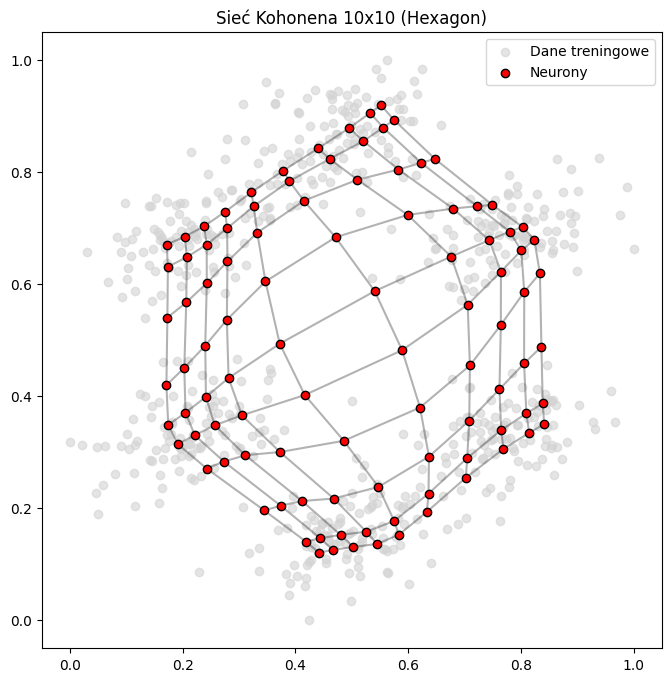

In [15]:
som = KohonenNetwork(m=10, n=10)
som.fit(X_gotowe_hex, epochs=100, neighborhood_func='gaussian', c=0.5)
plot_som_2d(X_gotowe_hex, som.weights, title="Sieć Kohonena 10x10 (Hexagon)")

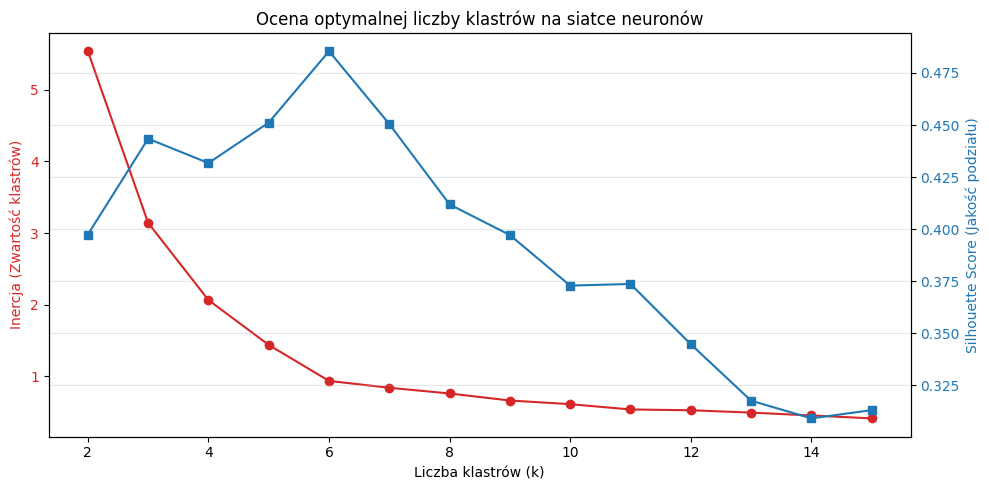

Sugerowana optymalna liczba klastrów (według najwyższego Silhouette): 6


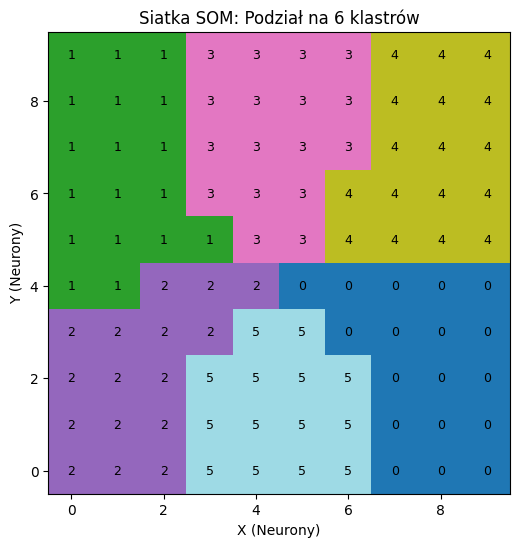

array([[2, 2, 2, 5, 5, 5, 5, 0, 0, 0],
       [2, 2, 2, 5, 5, 5, 5, 0, 0, 0],
       [2, 2, 2, 5, 5, 5, 5, 0, 0, 0],
       [2, 2, 2, 2, 5, 5, 0, 0, 0, 0],
       [1, 1, 2, 2, 2, 0, 0, 0, 0, 0],
       [1, 1, 1, 1, 3, 3, 4, 4, 4, 4],
       [1, 1, 1, 3, 3, 3, 4, 4, 4, 4],
       [1, 1, 1, 3, 3, 3, 3, 4, 4, 4],
       [1, 1, 1, 3, 3, 3, 3, 4, 4, 4],
       [1, 1, 1, 3, 3, 3, 3, 4, 4, 4]], dtype=int32)

In [16]:
evaluate_and_cluster_som(som_weights=som.weights)

In [18]:
statystyki_neuronow = licz_klasy_w_neuronach(som, X_gotowe_hex, etykiety_klas_hex)

print("\nPrzykładowe liczności w neuronach:")
for neuron_idx, zliczenia in list(statystyki_neuronow.items())[:5]:
    print(f"Współrzędne neuronu {neuron_idx}: {zliczenia}")

Liczba neuronów 'czystych' (tylko 1 klasa): 84
Liczba neuronów 'mieszanych' (>1 klas): 8

Przykładowe liczności w neuronach:
Współrzędne neuronu (np.int64(0), np.int64(6)): {np.int64(1): 9}
Współrzędne neuronu (np.int64(3), np.int64(9)): {np.int64(0): 16}
Współrzędne neuronu (np.int64(3), np.int64(2)): {np.int64(2): 10}
Współrzędne neuronu (np.int64(0), np.int64(4)): {np.int64(1): 19}
Współrzędne neuronu (np.int64(0), np.int64(1)): {np.int64(2): 14}


#### Testowanie różnych wartości szerokości sąsiedztwa

Zainicjalizowano wagi o wymiarach: (10, 10, 2)
Zakończono uczenie po 100 epokach.


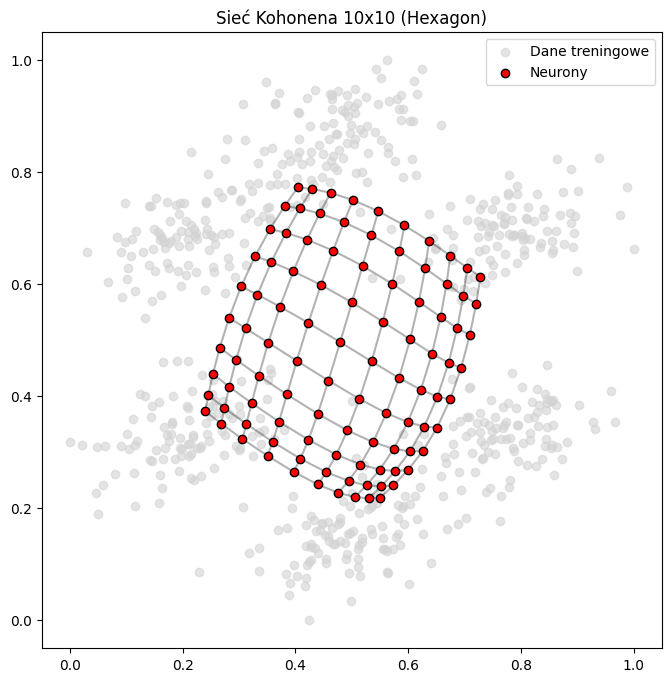

In [19]:
som = KohonenNetwork(m=10, n=10)
som.fit(X_gotowe_hex, epochs=100, neighborhood_func='gaussian', c=0.2)
plot_som_2d(X_gotowe_hex, som.weights, title="Sieć Kohonena 10x10 (Hexagon)")

Zainicjalizowano wagi o wymiarach: (10, 10, 2)
Zakończono uczenie po 100 epokach.


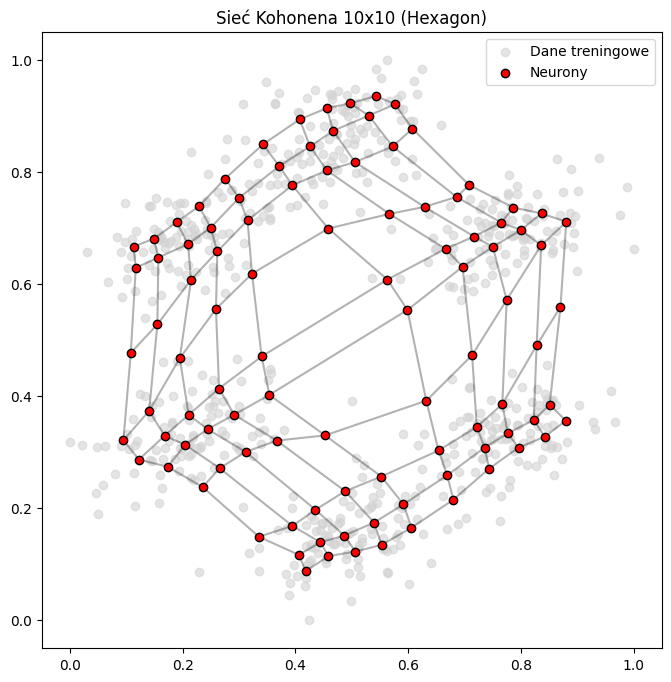

In [20]:
som = KohonenNetwork(m=10, n=10)
som.fit(X_gotowe_hex, epochs=100, neighborhood_func='gaussian', c=1.0)
plot_som_2d(X_gotowe_hex, som.weights, title="Sieć Kohonena 10x10 (Hexagon)")

Zainicjalizowano wagi o wymiarach: (10, 10, 2)
Zakończono uczenie po 100 epokach.


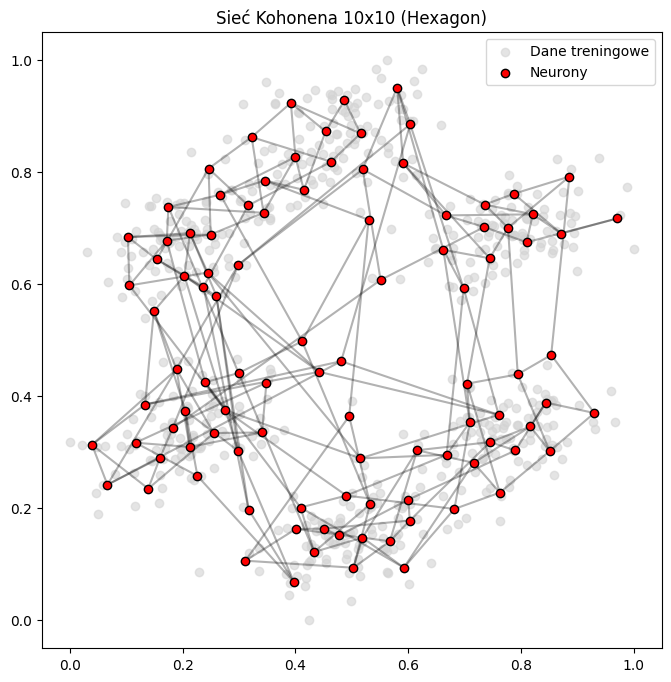

In [21]:
som = KohonenNetwork(m=10, n=10)
som.fit(X_gotowe_hex, epochs=100, neighborhood_func='gaussian', c=2)
plot_som_2d(X_gotowe_hex, som.weights, title="Sieć Kohonena 10x10 (Hexagon)")

Zainicjalizowano wagi o wymiarach: (10, 10, 2)
Zakończono uczenie po 100 epokach.


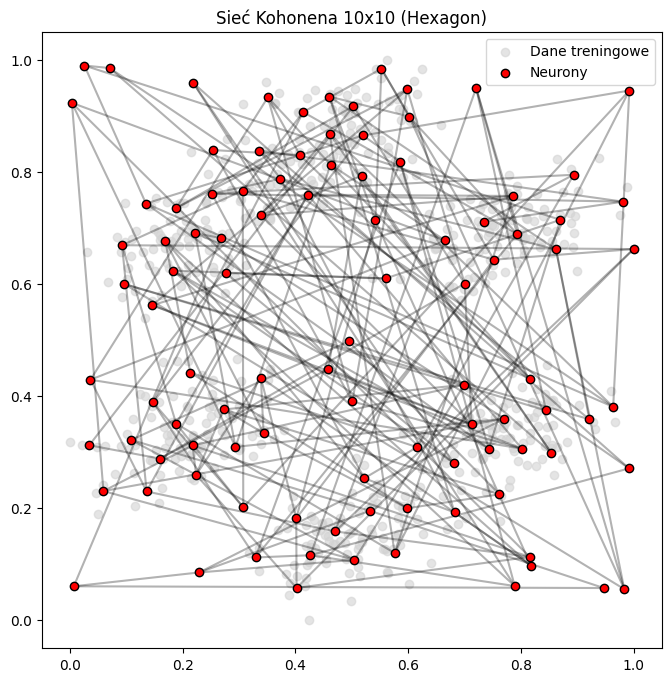

In [22]:
som = KohonenNetwork(m=10, n=10)
som.fit(X_gotowe_hex, epochs=100, neighborhood_func='gaussian', c=5)
plot_som_2d(X_gotowe_hex, som.weights, title="Sieć Kohonena 10x10 (Hexagon)")

### Zbiór CUBE